In [1]:
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import random
import os
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# 1. Configuración de Dispositivo
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"✅ Usando GPU NVIDIA: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available(): 
    device = torch.device("mps")
    print("✅ Usando GPU Apple (MPS)")
else:
    device = torch.device("cpu")
    print("⚠️ Usando CPU")

# 2. Reproducibilidad (Lo ponemos AL PRINCIPIO)
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed_everything(42) # Fijamos semilla aquí

✅ Usando GPU NVIDIA: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
# Carga de datos
df = pd.read_csv(r"C:\Users\julia\MGEO\THESIS\DEFORMATION_DATA\culstered_landslides_forNN_withRainfall\MedellinOriental_with_rainfall.csv")


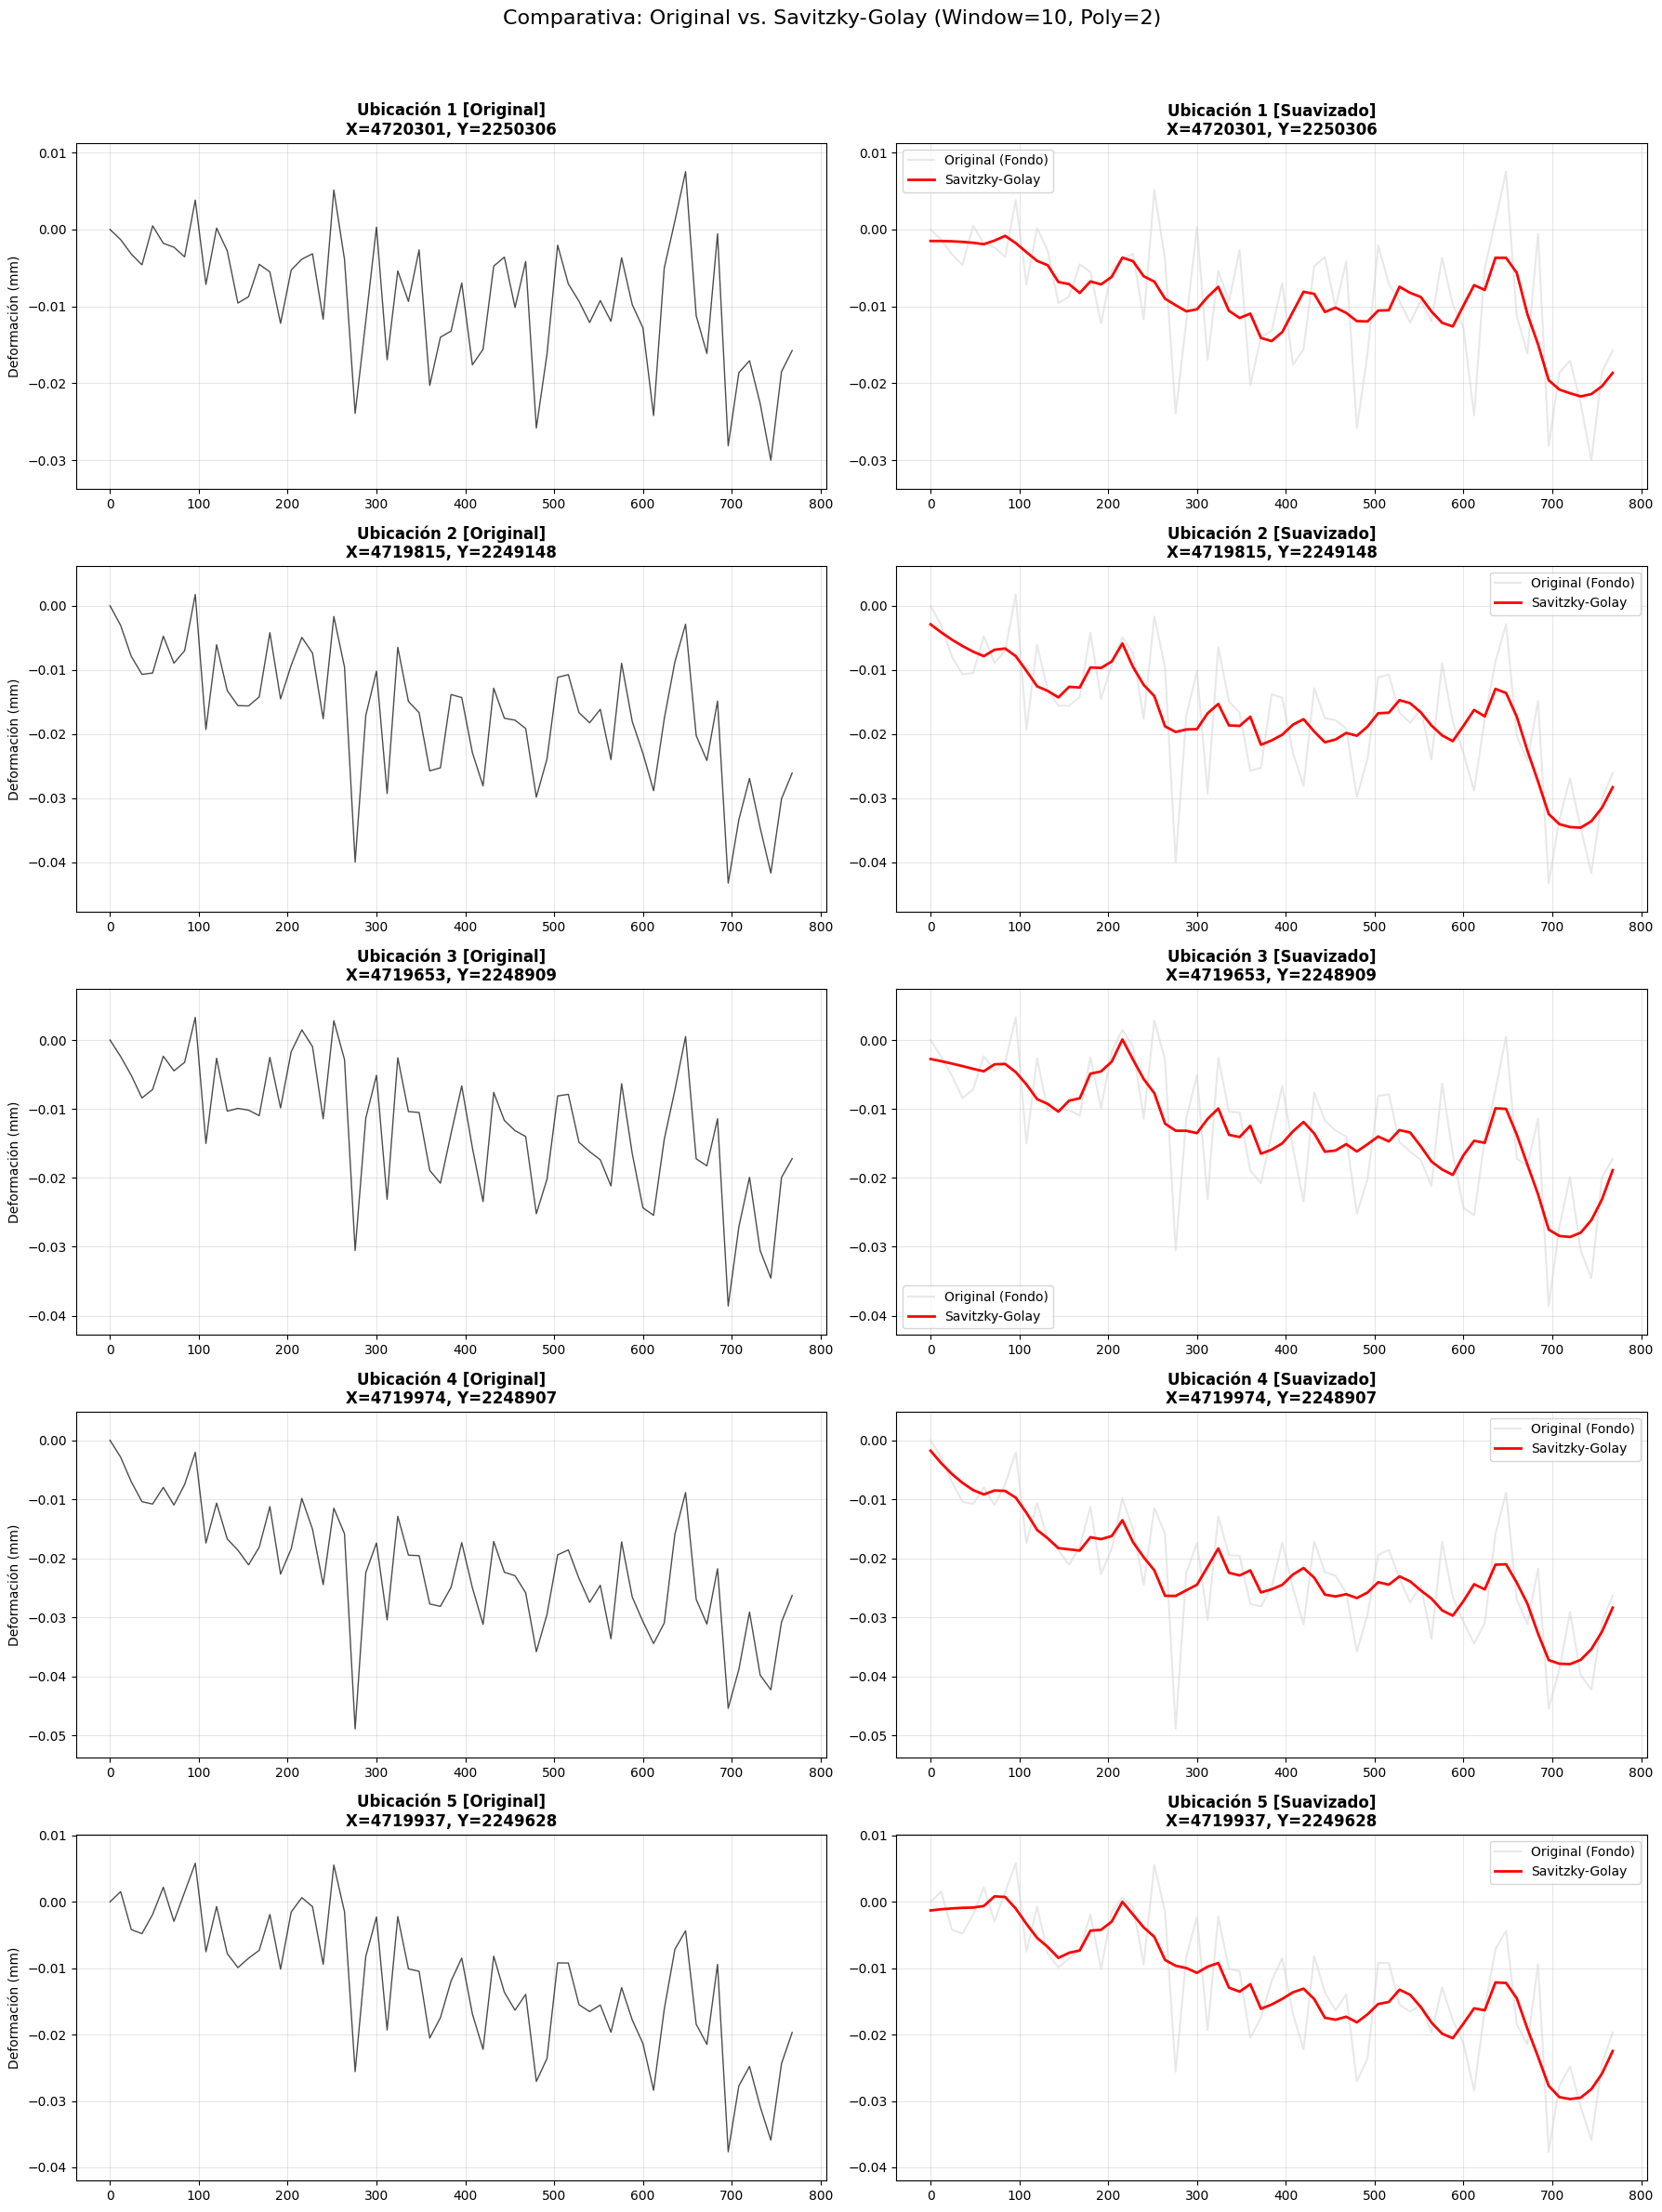

In [3]:
import matplotlib.pyplot as plt
import random
from scipy.signal import savgol_filter
import numpy as np

# --- CONFIGURACIÓN SAVITZKY-GOLAY ---
# window_length: Debe ser impar (ej. 15, 31, 51). Más grande = más suave.
# polyorder: Orden del polinomio (2 o 3 es lo estándar).
WINDOW_LEN = 10
POLY_ORDER = 2

# 1. Seleccionar 5 ubicaciones aleatorias únicas (X, Y)
unique_locs = list(df.groupby(['X', 'Y']).groups.keys())
selected_locs = random.sample(unique_locs, 5)

# 2. Configurar la figura (5 filas x 2 columnas = 10 gráficas)
fig, axes = plt.subplots(5, 2, figsize=(18, 25))
fig.suptitle(f'Comparativa: Original vs. Savitzky-Golay (Window={WINDOW_LEN}, Poly={POLY_ORDER})', fontsize=16)

for i, (x_loc, y_loc) in enumerate(selected_locs):
    # Obtener datos de esa ubicación ordenados por tiempo
    subset = df[(df['X'] == x_loc) & (df['Y'] == y_loc)].sort_values('t_days')
    
    t = subset['t_days'].values
    u_raw = subset['u'].values
    
    # --- APLICAR SAVITZKY-GOLAY ---
    try:
        if len(u_raw) > WINDOW_LEN:
            u_smooth = savgol_filter(u_raw, window_length=WINDOW_LEN, polyorder=POLY_ORDER)
        else:
            u_smooth = u_raw # Si la serie es muy corta, no filtrar
    except Exception as e:
        print(f"Error filtrando en {x_loc}, {y_loc}: {e}")
        u_smooth = u_raw

    # --- COLUMNA 1: SIN SUAVIZADO (Original) ---
    ax_raw = axes[i, 0]
    ax_raw.plot(t, u_raw, color='black', alpha=0.7, linewidth=1)
    ax_raw.set_title(f'Ubicación {i+1} [Original]\nX={x_loc:.0f}, Y={y_loc:.0f}', fontweight='bold')
    ax_raw.set_ylabel('Deformación (mm)')
    ax_raw.grid(True, alpha=0.3)

    # --- COLUMNA 2: CON SAVITZKY-GOLAY ---
    ax_smooth = axes[i, 1]
    # Dibujamos la original en gris tenue de fondo para referencia
    ax_smooth.plot(t, u_raw, color='lightgray', alpha=0.5, label='Original (Fondo)')
    # Dibujamos la suavizada en rojo intenso
    ax_smooth.plot(t, u_smooth, color='red', linewidth=2, label='Savitzky-Golay')
    
    ax_smooth.set_title(f'Ubicación {i+1} [Suavizado]\nX={x_loc:.0f}, Y={y_loc:.0f}', fontweight='bold')
    ax_smooth.grid(True, alpha=0.3)
    ax_smooth.legend()

    # Ajustar límites Y para que sean iguales en ambas columnas y comparar bien
    ymin = min(u_raw.min(), u_smooth.min())
    ymax = max(u_raw.max(), u_smooth.max())
    margin = (ymax - ymin) * 0.1
    ax_raw.set_ylim(ymin - margin, ymax + margin)
    ax_smooth.set_ylim(ymin - margin, ymax + margin)

plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Ajuste para que no tape el título principal
plt.show()

In [4]:
from scipy.signal import savgol_filter

def apply_savgol(x):
    # window_length: Tamaño de la ventana (debe ser impar, ej. 15)
    # polyorder: Orden del polinomio (ej. 2 o 3 para curvas suaves)
    try:
        if len(x) > 15: # Solo aplicar si la serie es suficientemente larga
            return savgol_filter(x, window_length=10, polyorder=2)
    except:
        pass
    return x

# Aplicar a cada grupo
df['u'] = df.groupby(['X', 'Y'])['u'].transform(apply_savgol)

In [5]:

# Ordenamiento crítico
df = df.sort_values(by=['X', 'Y', 't_days']).reset_index(drop=True)

# Corte temporal
cutoff_day = 600
train_df = df[df['t_days'] <= cutoff_day][['u','t_days', 'X', 'Y', 'p_acum_30d', 'p_acum_60d', 'p_acum_90d']].copy()
test_df = df[df['t_days'] > cutoff_day][['u', 't_days', 'X', 'Y', 'p_acum_30d', 'p_acum_60d', 'p_acum_90d']].copy()

# Escalado
scaler = MinMaxScaler()
feature_cols = ['u', 'X', 'Y', 'p_acum_30d', 'p_acum_60d', 'p_acum_90d', 't_days']
scaler.fit(train_df[feature_cols]) # Fit solo en train

# Transformar
train_df_scaled = pd.DataFrame(scaler.transform(train_df[feature_cols]), columns=feature_cols)
test_df_scaled = pd.DataFrame(scaler.transform(test_df[feature_cols]), columns=feature_cols)

# --- FUNCIÓN LIMPIA (Sin retorno de 't') ---
def create_sequences(df, n_steps_in, n_steps_out, feature_cols, target_col):
    X, y = [], []
    # Nota: Si X e Y son columnas del dataframe, groupby funciona bien
    grouped = df.groupby(['X', 'Y'])
    
    # Indices de columnas para numpy
    feat_idx = [df.columns.get_loc(c) for c in feature_cols]
    target_idx = df.columns.get_loc(target_col)
    
    for _, group in grouped:
        data = group.values
        
        for i in range(len(data) - n_steps_in - n_steps_out + 1):
            idx_end_input = i + n_steps_in
            idx_end_output = idx_end_input + n_steps_out
            
            # Secuencia de entrada (todas las features)
            X.append(data[i : idx_end_input, feat_idx])
            # Secuencia de salida (solo target 'u')
            y.append(data[idx_end_input : idx_end_output, target_idx])
            
    return np.array(X), np.array(y)

N_STEPS_IN = 5
N_STEPS_OUT = 1

X_train, y_train = create_sequences(train_df_scaled, N_STEPS_IN, N_STEPS_OUT, feature_cols, 'u')
X_test, y_test = create_sequences(test_df_scaled, N_STEPS_IN, N_STEPS_OUT, feature_cols, 'u')

# Creación de DataLoaders (Solo X e y)
batch_size = 32
train_loader = DataLoader(TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float()), shuffle=True, batch_size=batch_size)
test_loader = DataLoader(TensorDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).float()), shuffle=False, batch_size=batch_size)

print(f"Features de entrada: {X_train.shape[2]}")

Features de entrada: 7


In [6]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((31418, 5, 7), (31418, 1), (6147, 5, 7), (6147, 1))

In [7]:
# Índices
idx_target = feature_cols.index('u')

# Constantes para des-escalar (Llevadas a GPU una sola vez)
SCALE_U = torch.tensor(scaler.data_range_[idx_target]).float().to(device)
MIN_U = torch.tensor(scaler.data_min_[idx_target]).float().to(device)

print(f"Rango de Deformación (Escala): {SCALE_U.item():.4f}, Mínimo (Offset): {MIN_U.item():.4f}")

Rango de Deformación (Escala): 0.0511, Mínimo (Offset): -0.0448


In [8]:
class ViscoLSTM(nn.Module):
    def __init__(self, input_size=7, hidden_size=64, num_layers=2):
        super(ViscoLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

class SoilPhysics(nn.Module):
    def __init__(self):
        super().__init__()
        # Parámetros aprendibles (inicializados para suelo rígido)
        self.eta_raw = nn.Parameter(torch.tensor(10.0))
        self.c_prime_raw = nn.Parameter(torch.tensor(8.0))
        self.phi_raw = nn.Parameter(torch.tensor(15.0))
        self.n_exp_raw = nn.Parameter(torch.tensor(3.0))
        self.sigma_n_raw = nn.Parameter(torch.tensor(60.0)) 
        
        # Parámetros fijos
        self.register_buffer('tau_fixed', torch.tensor(30.0))
        self.h = 1000.0
        self.sigma_0 = 1.0

    def get_params(self):
        return {
            "eta": F.softplus(self.eta_raw),
            "c_prime": F.softplus(self.c_prime_raw),
            "phi": F.softplus(self.phi_raw),
            "n": F.softplus(self.n_exp_raw) + 1.0,
            "sigma_n": F.softplus(self.sigma_n_raw),
            "tau": self.tau_fixed
        }

def perzyna_loss_function(u_pred_mm, u_prev_mm, params, soil_physics_instance, dt_days=12.0):
    # Velocidad Cinemática (Observada)
    velocity = (u_pred_mm - u_prev_mm) / dt_days
    gamma_dot_kin = velocity / params['h']
    
    # Velocidad Dinámica (Teórica)
    phi_rad = torch.deg2rad(params['phi']) 
    yield_str = params['c_prime'] + params['sigma_n'] * torch.tan(phi_rad)
    
    # Overstress
    overstress = (params['tau'] - yield_str) / soil_physics_instance.sigma_0
    
    # Ley de potencia viscoplástica
    gamma_dot_dyn = (1.0 / params['eta']) * torch.pow(torch.relu(overstress), params['n'])
    
    return torch.mean((gamma_dot_kin - gamma_dot_dyn)**2)

# Instanciar
model = ViscoLSTM(input_size=len(feature_cols)).to(device)
soil_physics = SoilPhysics().to(device)
optimizer = optim.Adam(list(model.parameters()) + list(soil_physics.parameters()), lr=0.001)
criterion = nn.MSELoss()

In [9]:
def evaluate_model(loader, model, device, scale_u, min_u):
    model.eval()
    preds_mm = []
    targets_mm = []
    total_loss = 0
    
    with torch.no_grad():
        for X_b, y_b in loader: # Ya no hay t_b
            X_b, y_b = X_b.to(device), y_b.to(device)
            
            # Predicción
            pred_s = model(X_b)
            
            # Des-escalado
            pred_mm_batch = (pred_s * scale_u) + min_u
            target_mm_batch = (y_b * scale_u) + min_u
            
            # Guardar para métricas
            preds_mm.extend(pred_mm_batch.cpu().numpy().flatten())
            targets_mm.extend(target_mm_batch.cpu().numpy().flatten())
            
    return np.array(preds_mm), np.array(targets_mm)

In [10]:
from sklearn.metrics import mean_squared_error, r2_score # Aseguramos importación

epochs = 20
lambda_phy = 0.0001

# HE AÑADIDO 'TEST R2' DE VUELTA AL ENCABEZADO
print(f"{'Epoch':<6} | {'Total Loss':<10} | {'Data Loss':<10} | {'Phy Loss':<10} | {'TEST RMSE':<10} | {'TEST R2':<10}")
print("-" * 80)

for epoch in range(epochs):
    model.train()
    e_total = 0; e_data = 0; e_phy = 0
    
    for X_b, y_b in train_loader: 
        X_b, y_b = X_b.to(device), y_b.to(device)
        
        # 1. Forward
        u_pred_scaled = model(X_b)
        
        # 2. Física
        u_prev_scaled = X_b[:, -1, 0].unsqueeze(1) 
        u_diff_mm = (u_pred_scaled - u_prev_scaled) * SCALE_U 
        
        # 3. Losses
        loss_d = criterion(u_pred_scaled, y_b)
        
        curr_params = soil_physics.get_params()
        curr_params['h'] = soil_physics.h
        
        loss_p = perzyna_loss_function(u_diff_mm, torch.zeros_like(u_diff_mm), curr_params, soil_physics)
        
        loss = loss_d + (lambda_phy * loss_p)
        
        # 4. Backprop
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        e_total += loss.item()
        e_data += loss_d.item()
        e_phy += loss_p.item()

    # --- VALIDACIÓN ---
    # Usamos la función auxiliar para obtener predicciones limpias
    preds_val, targets_val = evaluate_model(test_loader, model, device, SCALE_U, MIN_U)
    
    # Calculamos ambas métricas
    rmse_val = np.sqrt(mean_squared_error(targets_val, preds_val))
    r2_val = r2_score(targets_val, preds_val) # <--- RESTAURADO
    
    # Imprimimos incluyendo R2
    n_batches = len(train_loader)
    print(f"{epoch+1:<6} | {e_total/n_batches:.5f}   | {e_data/n_batches:.5f}   | {e_phy/n_batches:.5f}   | {rmse_val:.4f}     | {r2_val:.4f}")

Epoch  | Total Loss | Data Loss  | Phy Loss   | TEST RMSE  | TEST R2   
--------------------------------------------------------------------------------
1      | 0.41886   | 0.00801   | 4108.46065   | 0.0081     | -0.3480
2      | 0.05894   | 0.00153   | 574.09912   | 0.0063     | 0.1842
3      | 0.02300   | 0.00104   | 219.50702   | 0.0054     | 0.4124
4      | 0.01134   | 0.00081   | 105.29738   | 0.0053     | 0.4312
5      | 0.00621   | 0.00066   | 55.43344   | 0.0055     | 0.3698
6      | 0.00363   | 0.00058   | 30.44714   | 0.0052     | 0.4535
7      | 0.00218   | 0.00048   | 17.02342   | 0.0047     | 0.5433
8      | 0.00136   | 0.00040   | 9.55315   | 0.0058     | 0.3091
9      | 0.00089   | 0.00036   | 5.33411   | 0.0055     | 0.3875
10     | 0.00061   | 0.00031   | 2.94779   | 0.0055     | 0.3910
11     | 0.00046   | 0.00030   | 1.60602   | 0.0046     | 0.5687
12     | 0.00036   | 0.00027   | 0.86116   | 0.0048     | 0.5231
13     | 0.00029   | 0.00024   | 0.45404   | 0.0048   


--- 📊 RESULTADOS EN TEST ---
RMSE (Error Cuadrático Medio): 0.00307 mm
MAE  (Error Absoluto Medio):   0.00268 mm
R²   (Coeficiente de Ajuste):  0.8067


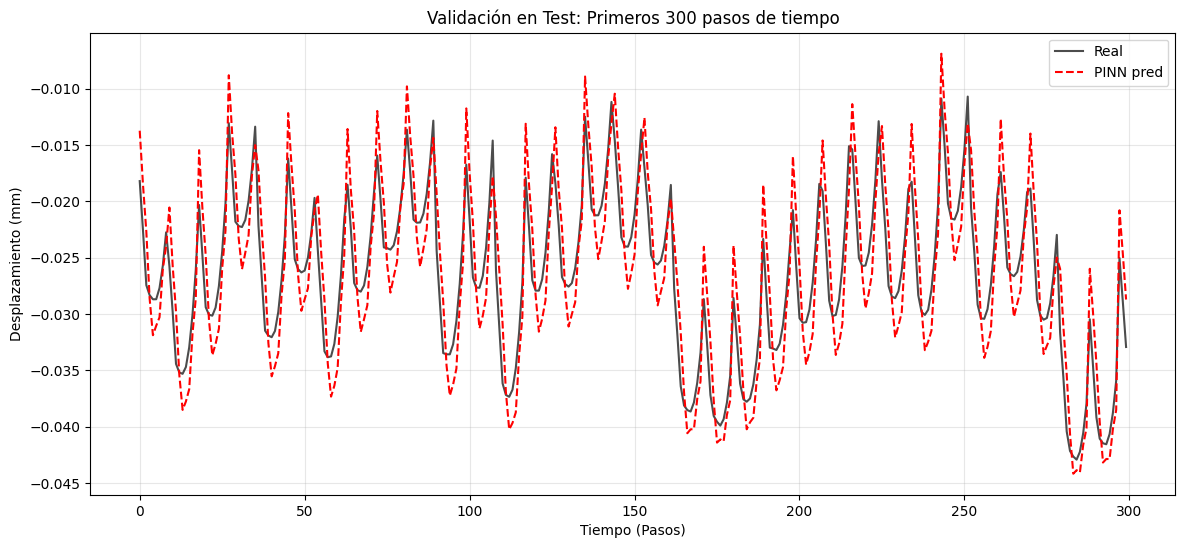

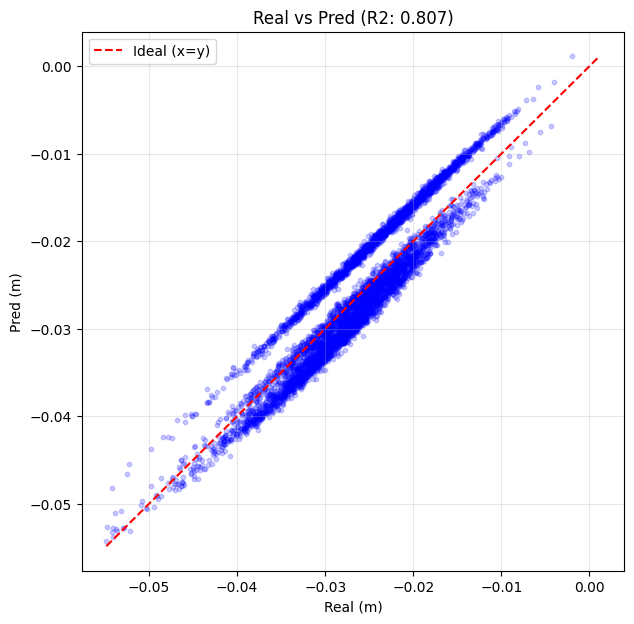


🌍 PARÁMETROS GEOTÉCNICOS APRENDIDOS:
---------------------------------------------
Eta (Viscosidad):      11.3365
Phi (Fricción):        17.0960°
Cohesión (c'):         10.0480 kPa
Esfuerzo Normal (sn):  62.1710 kPa
Exponente (n):         3.1080
Esfuerzo Cortante (tau): 30.0000 kPa (FIJO)
---------------------------------------------
🔍 DIAGNÓSTICO FÍSICO:
Resistencia del Suelo: 29.1696 kPa
Overstress (τ - τ_y):  0.8304 kPa
---------------------------------------------


In [11]:
import matplotlib.pyplot as plt
import math

# 1. EVALUACIÓN FINAL
# Usamos la función auxiliar para obtener predicciones limpias del Test Set
preds_final, targets_final = evaluate_model(test_loader, model, device, SCALE_U, MIN_U)

# 2. MÉTRICAS
rmse = np.sqrt(mean_squared_error(targets_final, preds_final))
r2 = r2_score(targets_final, preds_final)
mae = mean_absolute_error(targets_final, preds_final)

print("\n--- 📊 RESULTADOS EN TEST ---")
print(f"RMSE (Error Cuadrático Medio): {rmse:.5f} mm")
print(f"MAE  (Error Absoluto Medio):   {mae:.5f} mm")
print(f"R²   (Coeficiente de Ajuste):  {r2:.4f}")

# 3. GRÁFICA 1: SERIE DE TIEMPO (ZOOM)
limit = 300
plt.figure(figsize=(14, 6))
plt.plot(targets_final[:limit], label='Real', color='black', alpha=0.7, linewidth=1.5)
plt.plot(preds_final[:limit], label='PINN pred', color='red', linestyle='--', linewidth=1.5)
plt.title(f"Validación en Test: Primeros {limit} pasos de tiempo")
plt.xlabel("Tiempo (Pasos)")
plt.ylabel("Desplazamiento (mm)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. GRÁFICA 2: CORRELACIÓN (SCATTER) <- ¡LA QUE FALTABA!
plt.figure(figsize=(7, 7))
plt.scatter(targets_final, preds_final, alpha=0.2, color='blue', s=10)

# Línea de identidad (Perfecta predicción)
min_val = min(targets_final.min(), preds_final.min())
max_val = max(targets_final.max(), preds_final.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal (x=y)')

plt.xlabel("Real (m)")
plt.ylabel("Pred (m)")
plt.title(f"Real vs Pred (R2: {r2:.3f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. REPORTE GEOTÉCNICO DETALLADO (ESTILO ORIGINAL)
# Obtener los valores finales calibrados por la red
final_params = soil_physics.get_params()

# Extraer valores para facilitar el cálculo
tau_val = final_params['tau'].item()
sigma_n_val = final_params['sigma_n'].item()
c_val = final_params['c_prime'].item()
phi_val = final_params['phi'].item()
n_val = final_params['n'].item()
eta_val = final_params['eta'].item()

# Calcular Resistencia de Mohr-Coulomb (Yield Strength)
tan_phi = math.tan(math.radians(phi_val))
tau_yield = c_val + (sigma_n_val * tan_phi)
overstress = tau_val - tau_yield

print("\n🌍 PARÁMETROS GEOTÉCNICOS APRENDIDOS:")
print("-" * 45)
print(f"Eta (Viscosidad):      {eta_val:.4f}")
print(f"Phi (Fricción):        {phi_val:.4f}°")
print(f"Cohesión (c'):         {c_val:.4f} kPa")
print(f"Esfuerzo Normal (sn):  {sigma_n_val:.4f} kPa")
print(f"Exponente (n):         {n_val:.4f}")
print(f"Esfuerzo Cortante (tau): {tau_val:.4f} kPa (FIJO)")
print("-" * 45)

print(f"🔍 DIAGNÓSTICO FÍSICO:")
print(f"Resistencia del Suelo: {tau_yield:.4f} kPa")
print(f"Overstress (τ - τ_y):  {max(0, overstress):.4f} kPa")
print("-" * 45)